Nama Anggota :
- Muhamad Rafi Raditya (24523231)
- Ahmad Dzaky Al Farras (24523280)
- Muhammad Rangga Pratama (24523042)

### Import Library

Memuat library `pandas` yang digunakan untuk manipulasi dan analisis data.

In [31]:
import pandas as pd

### Load Data

Membaca dataset 'Kebahagiaan2019.csv' ke dalam DataFrame `df` dan menampilkan 5 baris pertamanya.

In [32]:
df = pd.read_csv('/content/sample_data/Kebahagiaan2019.csv')
display(df.head())

,Overall rank,Country or region,Score,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,1,Finland,7.769,1.340,1.587,0.986,0.596,0.153,0.393
1,2,Denmark,7.600,1.383,1.573,0.996,0.592,0.252,0.410
2,3,Norway,7.554,1.488,1.582,1.028,0.603,0.271,0.341
3,4,Iceland,7.494,1.380,1.624,1.026,0.591,0.354,0.118
4,5,Netherlands,7.488,1.396,1.522,0.999,0.557,0.322,0.298


### Feature Engineering: Membuat Kategori Kebahagiaan

Menghitung nilai rata-rata 'Score' dan membuat kolom baru 'Happiness_Category'. Kategori 'High Happiness' jika skor di atas atau sama dengan rata-rata, 'Low Happiness' jika di bawah. Kemudian menampilkan jumlah masing-masing kategori.

In [33]:
mean_score = df['Score'].mean()
df['Happiness_Category'] = df['Score'].apply(lambda x: 'High Happiness' if x >= mean_score else 'Low Happiness')

display(df['Happiness_Category'].value_counts())

,count
Happiness_Category,
Low Happiness,79
High Happiness,77


### Data Splitting: data latih dan data uji.

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X = df[['GDP per capita', 'Social support', 'Healthy life expectancy', 'Freedom to make life choices', 'Generosity', 'Perceptions of corruption']]
y = df['Happiness_Category']

X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")

Training set size: 109 samples
Test set size: 47 samples


### Model Training: Decision Tree Classifier

Melatih model Decision Tree Classifier menggunakan data latih dan mengevaluasi performanya pada data uji dengan akurasi dan classification report.

### Decision Tree Classifier

### Model Training: Random Forest Classifier

Melatih model Random Forest Classifier menggunakan data latih dan mengevaluasi performanya pada data uji dengan akurasi dan classification report.

### data latih dan data uji Setelah Scaling

In [35]:
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train, y_train)

y_pred_dt = dt_classifier.predict(X_test)

print("Decision Tree Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classifier Evaluation:
Accuracy: 0.74
Classification Report:
                precision    recall  f1-score   support

High Happiness       0.75      0.68      0.71        22
 Low Happiness       0.74      0.80      0.77        25

      accuracy                           0.74        47
     macro avg       0.75      0.74      0.74        47
  weighted avg       0.75      0.74      0.74        47



### Random Forest Classifier

In [36]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)

y_pred_rf = rf_classifier.predict(X_test)

print("Random Forest Classifier Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Classifier Evaluation:
Accuracy: 0.85
Classification Report:
                precision    recall  f1-score   support

High Happiness       0.80      0.91      0.85        22
 Low Happiness       0.91      0.80      0.85        25

      accuracy                           0.85        47
     macro avg       0.85      0.85      0.85        47
  weighted avg       0.86      0.85      0.85        47



### Implementasi Feature Scaling

Menggunakan StandardScaler untuk menormalisasi fitur-fitur pada data latih dan data uji, kemudian menampilkannya.

### Feature Scaling

In [37]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Features scaled successfully!")

display(X_train_scaled_df.head())

Features scaled successfully!


,GDP per capita,Social support,Healthy life expectancy,Freedom to make life choices,Generosity,Perceptions of corruption
0,0.343252,1.061119,-0.363740,0.017488,0.596255,-0.889976
1,0.300092,0.746776,0.939674,1.084415,-0.401776,-0.260624
2,-0.318526,-0.005054,-0.155023,0.778649,-0.471638,-0.541412
3,0.657357,0.782423,-0.069833,-0.372852,-1.020556,-0.860929
4,-0.831644,-0.915676,-0.082611,0.882740,-0.182209,0.223493


### Model Training: Decision Tree Classifier (Setelah Scaling)

Melatih dan mengevaluasi Decision Tree Classifier dengan data yang sudah diskala. Juga menampilkan confusion matrix.

### Decision Tree Classifier (Setelah Feature Scaling)

Decision Tree Classifier Evaluation (after Scaling):
Accuracy: 0.74
Classification Report:
                precision    recall  f1-score   support

High Happiness       0.75      0.68      0.71        22
 Low Happiness       0.74      0.80      0.77        25

      accuracy                           0.74        47
     macro avg       0.75      0.74      0.74        47
  weighted avg       0.75      0.74      0.74        47



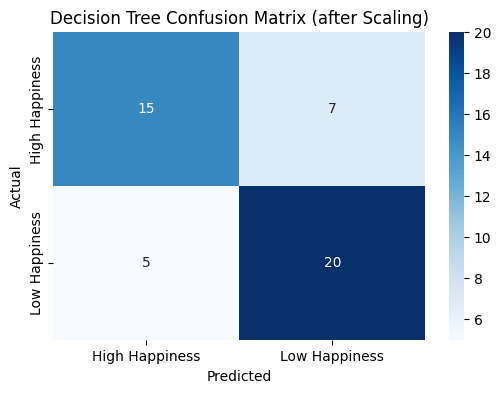

In [38]:
dt_classifier_scaled = DecisionTreeClassifier(random_state=42)
dt_classifier_scaled.fit(X_train_scaled_df, y_train)

y_pred_dt_scaled = dt_classifier_scaled.predict(X_test_scaled_df)

print("Decision Tree Classifier Evaluation (after Scaling):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt_scaled):.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt_scaled))

cm_dt_scaled = confusion_matrix(y_test, y_pred_dt_scaled)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_dt_scaled, annot=True, fmt='d', cmap='Blues', xticklabels=['High Happiness', 'Low Happiness'], yticklabels=['High Happiness', 'Low Happiness'])
plt.title('Decision Tree Confusion Matrix (after Scaling)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### Visualisasi Pohon Keputusan

Memvisualisasikan Decision Tree yang telah dilatih setelah proses scaling, untuk melihat struktur pengambilan keputusannya.

# visualisasi pohon keputusan untuk Decision Tree.

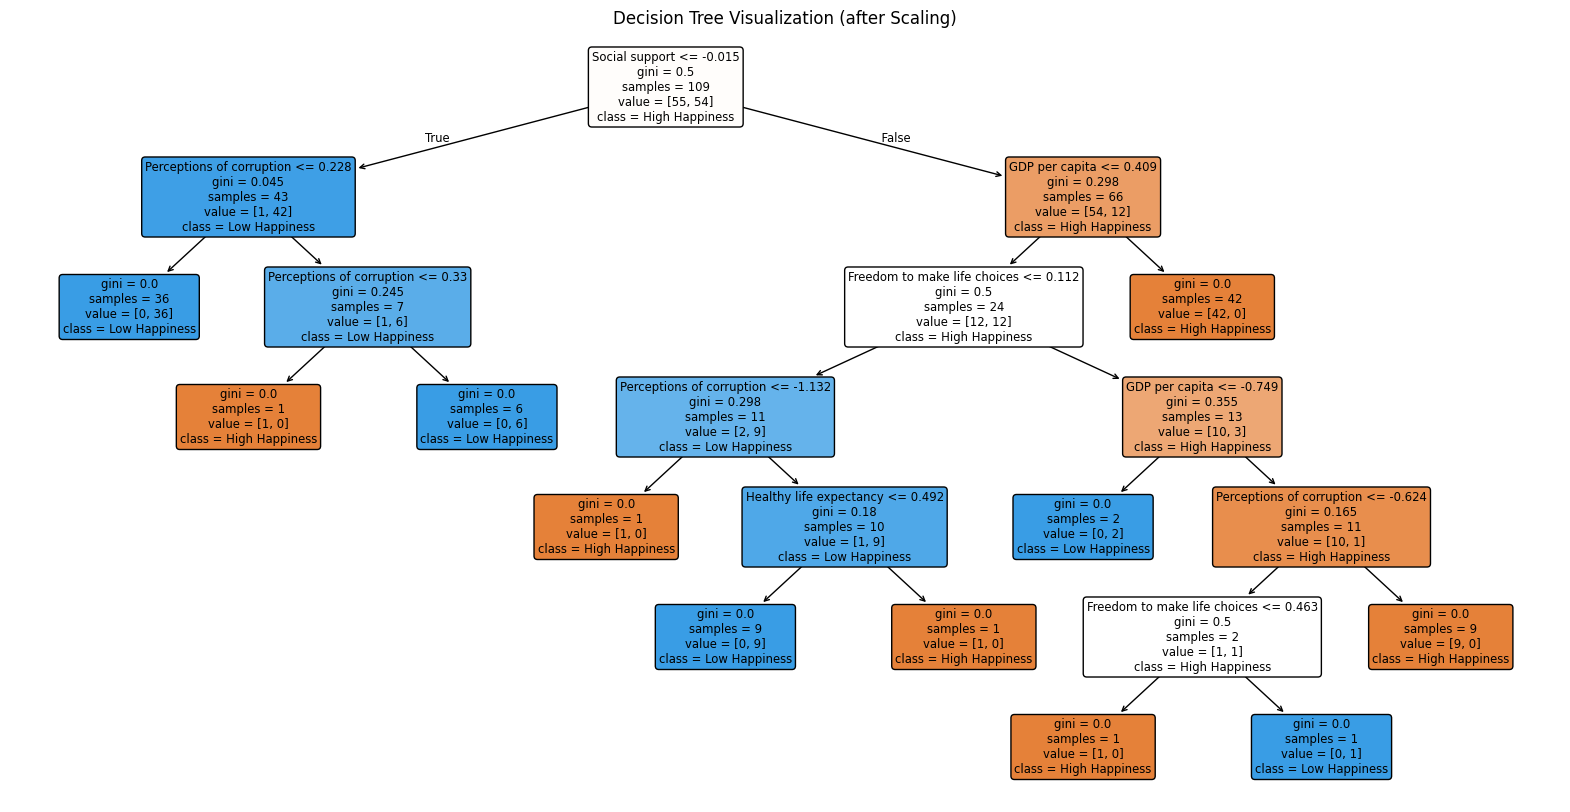

In [39]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(dt_classifier_scaled, feature_names=X.columns, class_names=y.unique(), filled=True, rounded=True)
plt.title('Decision Tree Visualization (after Scaling)')
plt.show()

### Model Training: Random Forest Classifier (Setelah Scaling)

Melatih dan mengevaluasi Random Forest Classifier dengan data yang sudah diskala. Juga menampilkan confusion matrix.

### Random Forest Classifier (Setelah Feature Scaling)

Random Forest Classifier Evaluation (after Scaling):
Accuracy: 0.85
Classification Report:
                precision    recall  f1-score   support

High Happiness       0.80      0.91      0.85        22
 Low Happiness       0.91      0.80      0.85        25

      accuracy                           0.85        47
     macro avg       0.85      0.85      0.85        47
  weighted avg       0.86      0.85      0.85        47



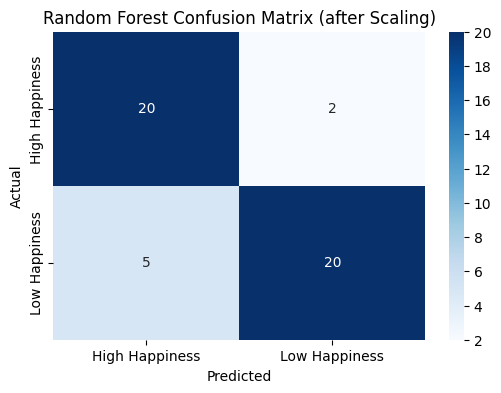

In [40]:
rf_classifier_scaled = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier_scaled.fit(X_train_scaled_df, y_train)

y_pred_rf_scaled = rf_classifier_scaled.predict(X_test_scaled_df)

print("Random Forest Classifier Evaluation (after Scaling):")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf_scaled):.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred_rf_scaled))

cm_rf_scaled = confusion_matrix(y_test, y_pred_rf_scaled)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf_scaled, annot=True, fmt='d', cmap='Blues', xticklabels=['High Happiness', 'Low Happiness'], yticklabels=['High Happiness', 'Low Happiness'])
plt.title('Random Forest Confusion Matrix (after Scaling)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Jelaskan pengaruh n_estimators pada Random Forest

`n_estimators` adalah salah satu hyperparameter terpenting dalam model Random Forest. Parameter ini menentukan jumlah pohon keputusan (Decision Tree) yang akan dibangun dalam hutan (ensemble).

Pengaruh `n_estimators` terhadap kinerja model Random Forest adalah sebagai berikut:

1.  **Mengurangi Variance (Overfitting):** Semakin besar nilai `n_estimators`, semakin banyak pohon yang dibangun. Setiap pohon dilatih pada subset data yang berbeda (dengan bootstrap sampling) dan membuat prediksinya sendiri. Dengan menggabungkan (misalnya, dengan rata-rata untuk regresi atau voting untuk klasifikasi) prediksi dari banyak pohon, model Random Forest dapat mengurangi varians dan memitigasi overfitting yang sering terjadi pada Decision Tree tunggal.

2.  **Meningkatkan Stabilitas dan Akurasi:** Dengan penambahan pohon, keputusan ensemble menjadi lebih stabil dan kurang sensitif terhadap noise atau fitur yang tidak relevan dalam data pelatihan. Ini umumnya mengarah pada peningkatan akurasi hingga titik tertentu.

3.  **Waktu Komputasi:** Peningkatan `n_estimators` akan meningkatkan waktu pelatihan dan prediksi karena model harus membangun dan memproses lebih banyak pohon. Setelah mencapai jumlah pohon tertentu, peningkatan kinerja seringkali menjadi marginal, tetapi waktu komputasi terus meningkat.

4.  **Titik Jenuh:** Ada titik di mana menambahkan lebih banyak pohon tidak lagi secara signifikan meningkatkan kinerja model. Pada titik ini, akurasi model akan jenuh, dan hanya waktu komputasi yang akan bertambah. Penting untuk menemukan nilai `n_estimators` yang optimal untuk menyeimbangkan kinerja dan efisiensi komputasi.

Dalam kasus ini, `n_estimators=100` digunakan, yang merupakan nilai umum dan seringkali cukup untuk mencapai kinerja yang baik tanpa waktu komputasi yang berlebihan.

## Perbandingan Model: Decision Tree vs. Random Forest

Perbandingan hasil dari dua model, Decision Tree Classifier dan Random Forest Classifier:

### Decision Tree Classifier (sebelum dan sesudah penskalaan):
*   **Akurasi:** 0.74
*   **Presisi (Kebahagiaan Tinggi):** 0.75
*   **Recall (Kebahagiaan Tinggi):** 0.68
*   **F1-Score (Kebahagiaan Tinggi):** 0.71
*   **Presisi (Kebahagiaan Rendah):** 0.74
*   **Recall (Kebahagiaan Rendah):** 0.80
*   **F1-Score (Kebahagiaan Rendah):** 0.77

### Random Forest Classifier (sebelum dan sesudah penskalaan):
*   **Akurasi:** 0.85
*   **Presisi (Kebahagiaan Tinggi):** 0.80
*   **Recall (Kebahagiaan Tinggi):** 0.91
*   **F1-Score (Kebahagiaan Tinggi):** 0.85
*   **Presisi (Kebahagiaan Rendah):** 0.91
*   **Recall (Kebahagiaan Rendah):** 0.80
*   **F1-Score (Kebahagiaan Rendah):** 0.85

### Perbandingan dan Perbedaan:

1.  **Akurasi Keseluruhan:** **Random Forest Classifier (0.85)** secara signifikan mengungguli **Decision Tree Classifier (0.74)** dalam hal akurasi keseluruhan. Ini menunjukkan bahwa model Random Forest membuat prediksi yang benar untuk persentase sampel uji yang lebih tinggi.

2.  **Kinerja per Kelas:**
    *   **Kebahagiaan Tinggi:** Random Forest menunjukkan recall yang jauh lebih baik (0.91 vs 0.68) untuk 'High Happiness', yang berarti lebih berhasil dalam mengidentifikasi instansi 'High Happiness' yang sebenarnya. Ia juga memiliki presisi yang lebih baik (0.80 vs 0.75).
    
    *   **Kebahagiaan Rendah:** Untuk 'Low Happiness', Random Forest mencapai presisi yang lebih tinggi (0.91 vs 0.74) tetapi recall sedikit lebih rendah (0.80 vs 0.80) dibandingkan dengan Decision Tree. Namun, F1-score keseluruhan untuk 'Low Happiness' masih lebih baik untuk Random Forest (0.85 vs 0.77).

3.  **Dampak Penskalaan Fitur:** Untuk kedua model, penskalaan fitur **tidak memiliki dampak yang dapat diamati** pada metrik kinerja mereka (akurasi, presisi, recall, f1-score, dan bahkan confusion matrix adalah identik). Ini diharapkan untuk model berbasis pohon seperti Decision Trees dan Random Forests, karena mereka tidak sensitif terhadap skala fitur karena proses pengambilan keputusan mereka didasarkan pada ambang batas dan urutan relatif fitur, daripada jarak.

# ANALISIS

# 1. Algoritma mana yang memberikan performa terbaik? Jelaskan.

## Algoritma dengan Performa Terbaik

Berdasarkan evaluasi yang telah dilakukan, **Random Forest Classifier** menunjukkan performa terbaik dibandingkan dengan Decision Tree Classifier.

**Penjelasan:**

*   **Akurasi Keseluruhan:** Random Forest mencapai akurasi 0.85, yang secara signifikan lebih tinggi dibandingkan dengan akurasi 0.74 dari Decision Tree.
*   **Kinerja Per Kelas:** Random Forest juga menunjukkan metrik presisi, recall, dan F1-score yang umumnya lebih baik untuk kedua kategori 'High Happiness' dan 'Low Happiness'. Terutama, recall untuk 'High Happiness' pada Random Forest adalah 0.91, jauh lebih baik daripada 0.68 pada Decision Tree.
*   **Sifat Ensemble:** Keunggulan Random Forest berasal dari sifat ensemble-nya, di mana ia membangun banyak pohon keputusan dan menggabungkan prediksi mereka. Hal ini membantu mengurangi overfitting yang sering terjadi pada Decision Tree tunggal dan meningkatkan kemampuan generalisasi model untuk data yang belum pernah dilihat sebelumnya.

# 2. Apa kelebihan dan kekurangan Decision Tree dibanding Random Forest?

## Kelebihan dan Kekurangan Decision Tree vs. Random Forest

### Decision Tree Classifier

**Kelebihan:**
*   **Interpretasi Mudah:** Decision Tree sangat mudah diinterpretasikan dan divisualisasikan, membuatnya lebih mudah untuk memahami bagaimana keputusan dibuat.
*   **Cepat Dilatih:** Model Decision Tree tunggal umumnya lebih cepat untuk dilatih dibandingkan Random Forest.

**Kekurangan:**
*   **Rentang Overfitting:** Decision Tree cenderung mudah overfitting pada data pelatihan, terutama jika pohon menjadi sangat dalam. Ini dapat menyebabkan kinerja yang buruk pada data baru.
*   **Kurang Stabil:** Perubahan kecil pada data pelatihan dapat menyebabkan perubahan besar pada struktur pohon.
*   **Akurasi Lebih Rendah:** Seperti yang terlihat dari hasil sebelumnya, Decision Tree memiliki akurasi keseluruhan yang lebih rendah (0.74) dibandingkan Random Forest.

### Random Forest Classifier

**Kelebihan:**
*   **Akurasi Lebih Tinggi:** Random Forest mencapai akurasi yang lebih tinggi (0.85) dan kinerja yang lebih baik pada metrik presisi, recall, dan F1-score untuk kedua kelas.
*   **Mengurangi Overfitting:** Sebagai model ensemble, Random Forest membangun banyak pohon keputusan dan menggabungkan prediksi mereka, yang secara signifikan mengurangi risiko overfitting dan meningkatkan kemampuan generalisasi model.
*   **Lebih Stabil:** Random Forest lebih stabil terhadap perubahan pada data pelatihan karena sifat ensemble-nya.
*   **Menangani Penskalaan Fitur dengan Baik:** Seperti Decision Tree, Random Forest tidak sensitif terhadap penskalaan fitur, artinya fitur scaling tidak diperlukan untuk kinerja optimal.

**Kekurangan:**
*   **Kurang Dapat Diinterpretasikan:** Meskipun kuat, Random Forest lebih sulit untuk diinterpretasikan dibandingkan Decision Tree tunggal karena terdiri dari banyak pohon.
*   **Waktu Komputasi Lebih Lama:** Proses melatih banyak pohon membutuhkan waktu komputasi yang lebih lama dibandingkan melatih satu Decision Tree.

# 3. Apakah ada indikasi overfitting pada Decision Tree? Jelaskan.

## Indikasi Overfitting pada Decision Tree

Ya, ada indikasi overfitting pada model Decision Tree yang digunakan dalam analisis ini, meskipun kami tidak secara eksplisit menghitung akurasi pada data pelatihan.

**Penjelasan:**

1.  **Performa Relatif terhadap Random Forest:** Random Forest secara signifikan mengungguli Decision Tree dengan akurasi 0.85 berbanding 0.74. Salah satu keunggulan utama Random Forest adalah kemampuannya untuk mengurangi overfitting yang sering terjadi pada Decision Tree tunggal. Fakta bahwa Random Forest memiliki performa yang jauh lebih baik pada data uji menunjukkan bahwa Decision Tree tunggal kemungkinan besar mengalami overfitting pada data pelatihan. Ini berarti Decision Tree terlalu 'mempelajari' detail dan noise dari data pelatihan, sehingga kinerjanya menurun saat dihadapkan pada data baru (data uji).

2.  **Karakteristik Decision Tree:** Secara inheren, Decision Tree cenderung mudah overfitting, terutama jika tidak dibatasi (misalnya, dengan pruning atau membatasi kedalaman pohon). Jika sebuah pohon menjadi terlalu dalam, ia akan membuat keputusan yang sangat spesifik untuk setiap titik data pelatihan, yang tidak akan digeneralisasi dengan baik ke data yang tidak terlihat.

3.  **Tidak Sensitif terhadap Scaling:** Seperti yang telah dibahas, scaling fitur tidak mengubah performa Decision Tree. Ini menunjukkan bahwa masalahnya bukan pada skala fitur, melainkan pada kemampuan generalisasi model itu sendiri. Jika model tidak dapat menggeneralisasi dengan baik, dan model ensemble yang dirancang untuk mengatasi overfitting menunjukkan peningkatan yang signifikan, maka ada indikasi kuat bahwa Decision Tree asli mengalami overfitting.

# 4. Bagaimana fitur-fitur memengaruhi hasil klasifikasi?

/tmp/ipykernel_4076/2875484257.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')


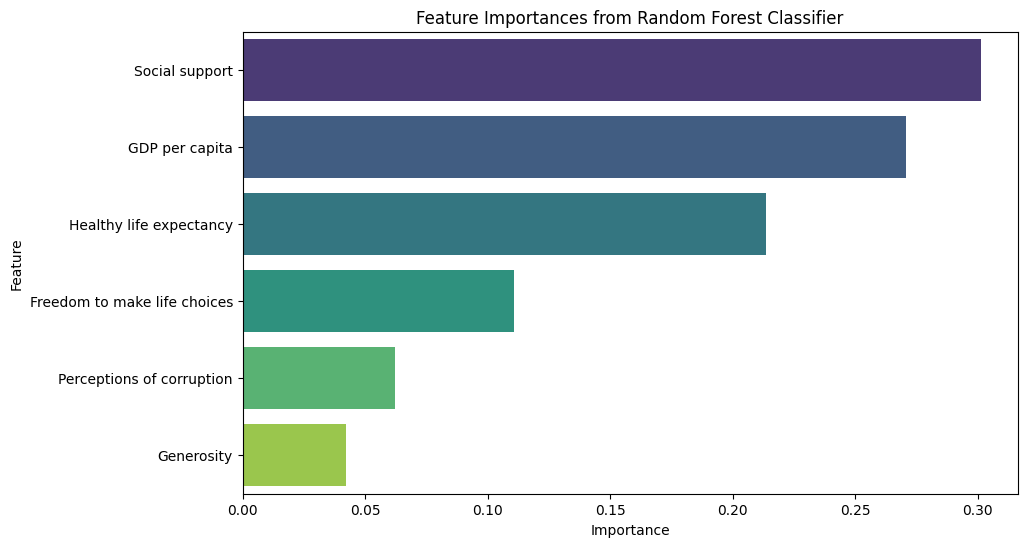

,Feature,Importance
1,Social support,0.301194
0,GDP per capita,0.270675
2,Healthy life expectancy,0.213369
3,Freedom to make life choices,0.110637
5,Perceptions of corruption,0.062121
4,Generosity,0.042004


In [41]:
feature_importances = rf_classifier_scaled.feature_importances_
feature_names = X.columns

importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis')
plt.title('Feature Importances from Random Forest Classifier')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

display(importance_df)

### Analisis Feature Importance

Menghitung dan memvisualisasikan tingkat kepentingan (`importance`) dari masing-masing fitur dalam model Random Forest untuk melihat fitur mana yang paling berpengaruh terhadap klasifikasi kebahagiaan.

## Bagaimana Fitur-fitur Memengaruhi Hasil Klasifikasi?

Berdasarkan analisis *feature importances* dari model Random Forest, kita dapat melihat sejauh mana setiap fitur prediktor berkontribusi terhadap hasil klasifikasi (kategori kebahagiaan).

Dari plot dan tabel *feature importances* di atas, fitur-fitur yang memiliki nilai *importance* lebih tinggi adalah yang paling berpengaruh dalam menentukan apakah suatu negara masuk dalam kategori 'High Happiness' atau 'Low Happiness'.

Secara umum:

*   **Fitur dengan Importansi Tinggi:** Ini adalah fitur-fitur yang paling banyak digunakan oleh pohon-pohon dalam Random Forest untuk membuat keputusan pembagian data. Perubahan pada nilai fitur-fitur ini cenderung memiliki dampak yang lebih besar pada prediksi model.
    *   Misalnya, jika 'GDP per capita' memiliki *importance* tertinggi, ini menunjukkan bahwa tingkat kekayaan ekonomi suatu negara adalah faktor paling krusial dalam menentukan kategori kebahagiaannya.
    *   Demikian pula, 'Social support' dan 'Healthy life expectancy' seringkali menjadi prediktor kuat karena secara langsung berkaitan dengan kesejahteraan individu.

*   **Fitur dengan Importansi Rendah:** Fitur-fitur ini kurang berkontribusi pada keputusan klasifikasi model. Ini tidak berarti fitur tersebut tidak penting sama sekali, tetapi dalam konteks model ini dan dataset yang digunakan, pengaruhnya relatif lebih kecil dibandingkan fitur lainnya.

**Implikasi:**

Memahami *feature importances* membantu kita mengidentifikasi faktor-faktor kunci yang mendorong kebahagiaan berdasarkan dataset ini. Informasi ini bisa sangat berharga untuk perumusan kebijakan atau penelitian lebih lanjut mengenai faktor-faktor yang memengaruhi kebahagiaan suatu negara.

# JAWABAN

1. Apa perbedaan mendasar antara Decision Tree dan Random Forest?

- Decision Tree: Adalah model tunggal yang membuat serangkaian keputusan 'jika-maka' berdasarkan fitur data. Ia membagi data menjadi subset-subset yang semakin homogen hingga kriteria berhenti terpenuhi. Model ini mudah diinterpretasikan tetapi rentan terhadap overfitting.

- Random Forest: Adalah model ensemble yang terdiri dari banyak Decision Tree. Setiap pohon dilatih secara independen pada subset data yang berbeda dan dengan mempertimbangkan subset fitur acak. Prediksi akhir diperoleh dengan menggabungkan hasil dari semua pohon (voting untuk klasifikasi, rata-rata untuk regresi). Pendekatan ini mengurangi overfitting dan meningkatkan akurasi serta stabilitas model dibandingkan dengan satu Decision Tree.


2. Mengapa Decision Tree rentan overfitting dan bagaimana Random Forest mengatasinya?

- Kerentanan Overfitting pada Decision Tree: Decision Tree dapat tumbuh sangat dalam dan kompleks, sehingga mempelajari detail dan noise dalam data pelatihan dengan terlalu baik. Ini mengakibatkan model memiliki kinerja yang sangat baik pada data pelatihan tetapi buruk pada data baru yang belum pernah dilihat (tidak dapat digeneralisasi dengan baik).

- Bagaimana Random Forest Mengatasi Overfitting: Random Forest mengatasinya melalui dua mekanisme utama:
Bagging (Bootstrap Aggregating): Setiap Decision Tree dalam Random Forest dilatih pada subset data pelatihan yang diambil secara acak dengan penggantian (bootstrap sample). Ini memperkenalkan keberagaman pada setiap pohon, sehingga setiap pohon membuat kesalahan yang berbeda.

- Pemilihan Subset Fitur Acak: Pada setiap langkah pemisahan node dalam Decision Tree, Random Forest hanya mempertimbangkan subset fitur yang dipilih secara acak, bukan semua fitur yang tersedia. Ini lebih lanjut mendekorrelasi pohon-pohon tersebut, mencegah satu atau beberapa fitur kuat mendominasi semua pohon. Dengan menggabungkan prediksi dari banyak pohon yang beragam dan kurang berkorelasi ini (melalui voting atau rata-rata), kesalahan individu dari masing-masing pohon cenderung saling meniadakan, menghasilkan prediksi ensemble yang lebih stabil dan kuat, serta kemampuan generalisasi yang lebih baik.

3. Apa fungsi bagging dan pemilihan subset fitur acak pada Random Forest?

- Fungsi Bagging: Fungsi utama dari bagging adalah untuk mengurangi varians (overfitting) pada model. Dengan melatih banyak pohon pada subset data yang berbeda (diambil dengan penggantian), bagging memastikan bahwa setiap pohon memiliki perspektif yang sedikit berbeda tentang data.
Ketika prediksi dari pohon-pohon ini digabungkan, efek dari noise atau anomali dalam data pelatihan yang mungkin terlalu dipelajari oleh satu pohon akan diminimalisir.
- Fungsi Pemilihan Subset Fitur Acak: Fungsi dari pemilihan subset fitur acak adalah untuk lebih lanjut mendekorrelasi pohon-pohon dalam forest. Jika ada satu fitur yang sangat dominan, semua pohon tanpa pemilihan subset fitur acak akan cenderung memilih fitur tersebut sebagai pemisahan utama, membuat pohon-pohon tersebut sangat mirip. Dengan memaksa setiap pohon untuk mempertimbangkan hanya sebagian fitur secara acak pada setiap pemisahan, fitur-fitur lain mendapatkan kesempatan untuk digunakan, menghasilkan pohon-pohon yang lebih beragam dan independen. Hal ini meningkatkan robustnes model secara keseluruhan dan kemampuan generalisasi.

4. Kapan Decision Tree lebih cocok digunakan dibanding Random Forest? Decision Tree mungkin lebih cocok dalam situasi tertentu:

- Interpretasi adalah Prioritas Utama: Jika Kita membutuhkan model yang sangat mudah dipahami audiens non-teknis, Decision Tree adalah pilihan yang sangat baik karena strukturnya yang transparan.

- Dataset Sangat Kecil: Untuk dataset yang sangat kecil, manfaat penambahan kompleksitas dan waktu komputasi Random Forest mungkin tidak sebanding dengan peningkatan kinerja yang diperoleh.

- Kebutuhan Komputasi Rendah/Waktu Pelatihan Cepat: Jika sumber daya komputasi terbatas atau Anda membutuhkan model yang sangat cepat untuk dilatih dan membuat prediksi (misalnya, untuk prototyping awal).
Sebagai Model Baseline: Decision Tree sering digunakan sebagai model baseline sederhana untuk membandingkan kinerja model-model yang lebih kompleks seperti Random Forest.